In [1]:
# ==============================
# Customer Churn Prediction
# Exploratory Data Analysis (EDA)
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [2]:
# Load Dataset

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# Display First 5 Rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7043
Columns : 21


In [5]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Statistical Summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Missing Values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
# Data Types

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [10]:
# Column Names

df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [11]:
# Target Variable Distribution

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
# Churn Percentage

df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

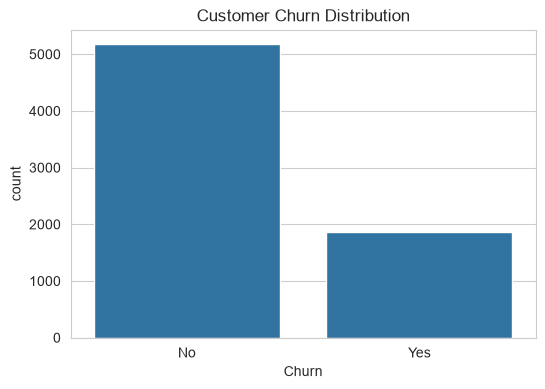

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

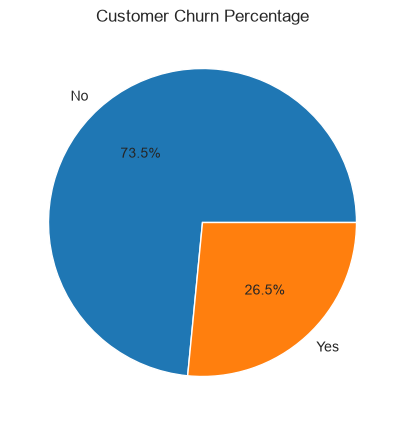

In [14]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)

plt.title("Customer Churn Percentage")

plt.ylabel("")

plt.show()

# Observation

• Dataset contains 7043 customer records.
• Dataset contains 21 columns.
• Around 73% customers stayed.
• Around 27% customers churned.
• Dataset is moderately imbalanced.

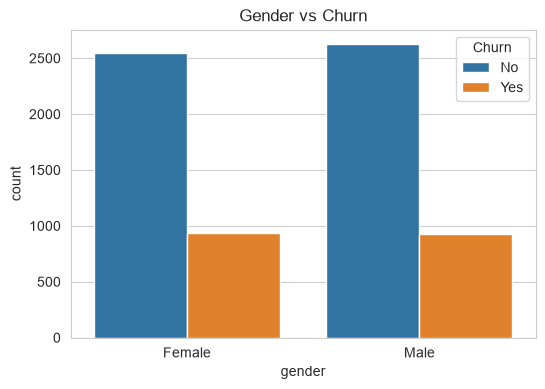

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Churn")
plt.show()

# Observation

• Male and Female customers are almost equally distributed.
• Churn rate appears similar for both genders.
• Gender alone is not a strong predictor of churn.

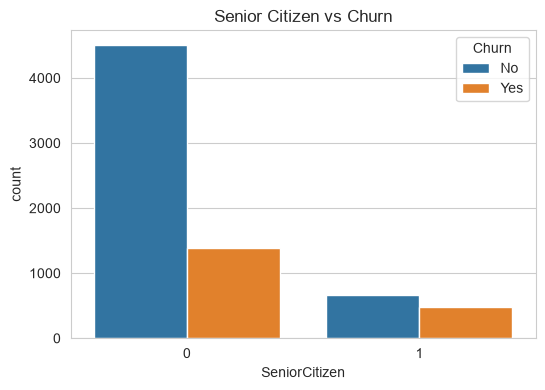

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Churn")
plt.show()

Senior citizens show a higher churn rate compared to non-senior customers.

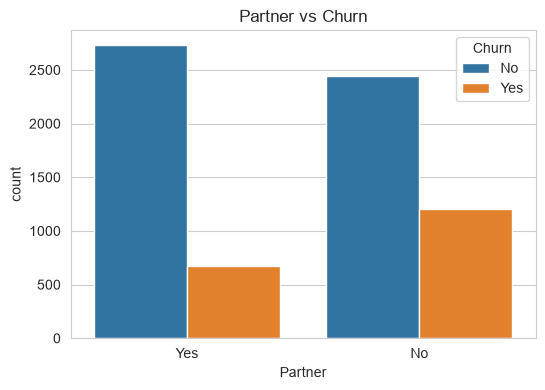

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Partner", hue="Churn", data=df)

plt.title("Partner vs Churn")
plt.show()

Customers without a partner tend to churn more frequently.

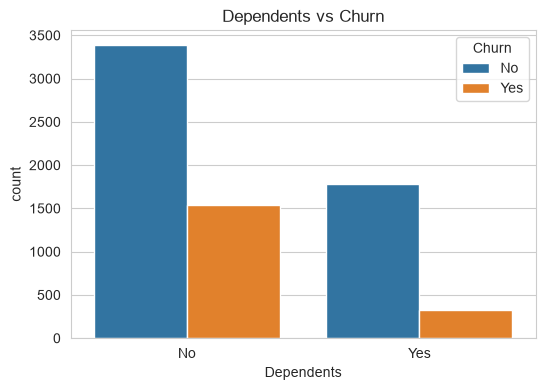

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Dependents", hue="Churn", data=df)

plt.title("Dependents vs Churn")
plt.show()

Customers without dependents have a higher churn rate.

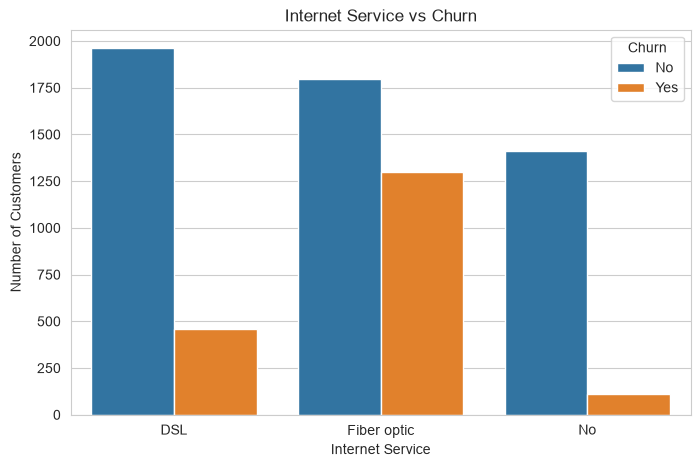

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

Observation

• Customers using Fiber Optic internet have the highest churn rate.
• DSL customers have comparatively lower churn.
• Customers without internet service rarely churn.

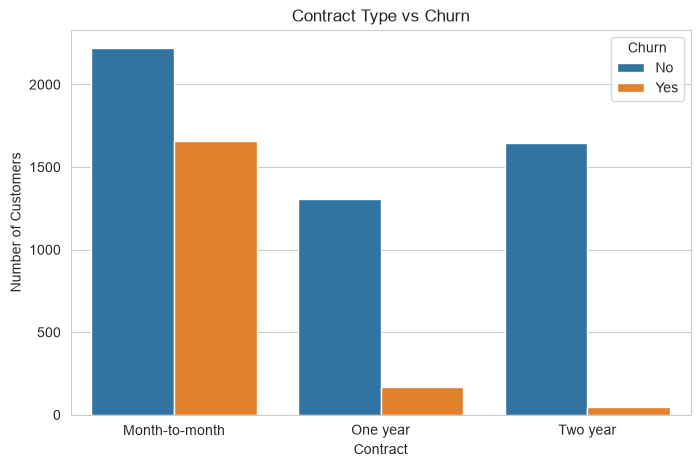

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.show()

Observation

• Month-to-Month customers churn significantly more.
• One-Year and Two-Year contract customers are more loyal.
• Longer contracts reduce customer churn.

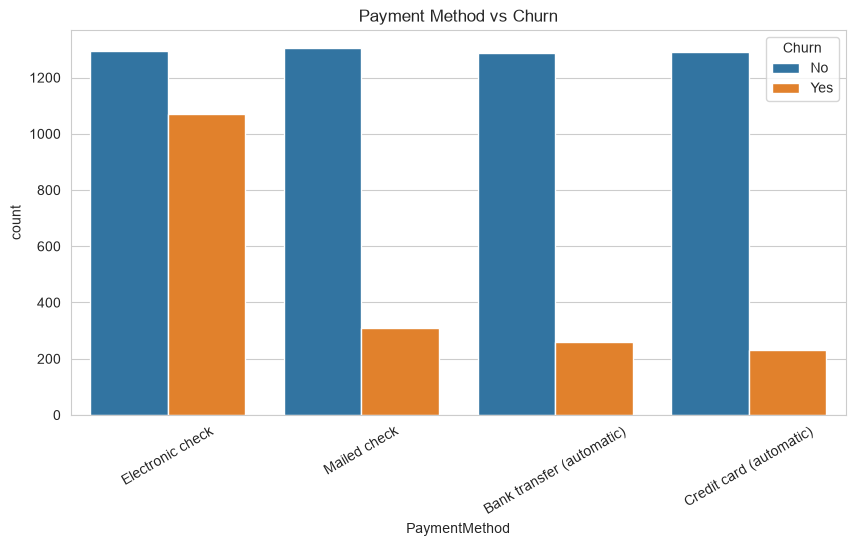

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

Observation

• Electronic Check users have the highest churn rate.
• Automatic payment methods show better customer retention.

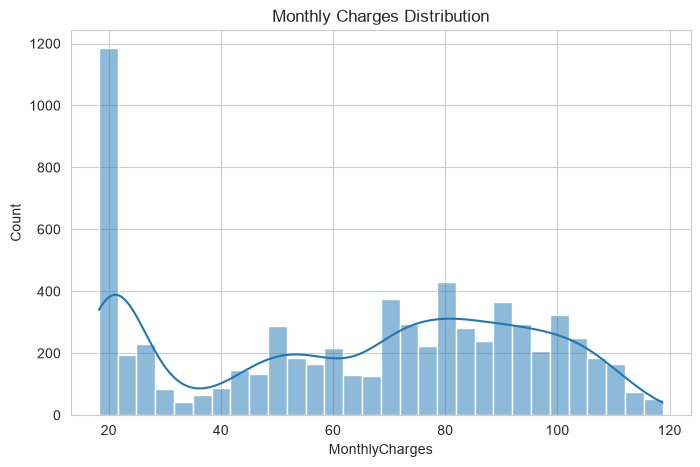

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.show()

Observation

• Monthly charges vary from low to high.
• Most customers pay between $20 and $100.

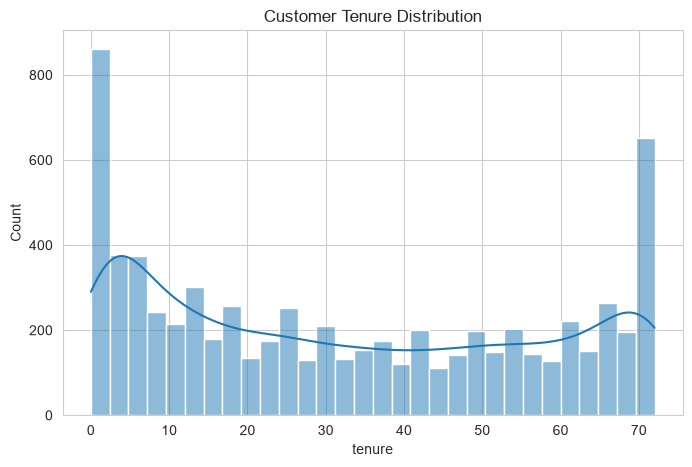

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.show()

Observation

• Many customers are new.
• Long-term customers are comparatively stable.

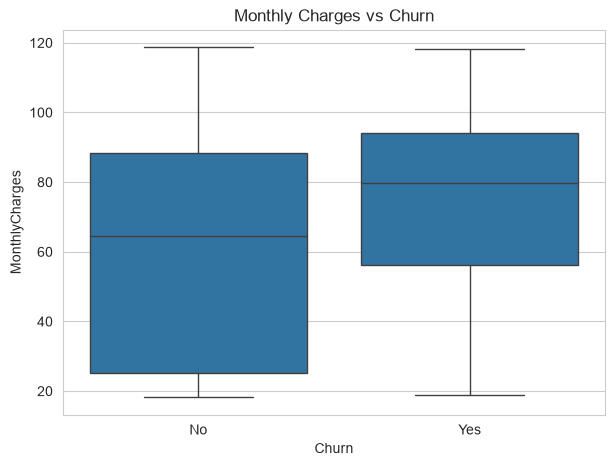

In [24]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

Observation

• Customers with higher monthly charges tend to churn more frequently.

In [25]:
# Feature Engineering 1: Total Charges per Tenure

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Avoid division by zero
df["TotalChargesPerTenure"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

print("TotalChargesPerTenure feature created successfully")

df[["tenure", "TotalCharges", "MonthlyCharges", "TotalChargesPerTenure"]].head()

TotalChargesPerTenure feature created successfully


,tenure,TotalCharges,MonthlyCharges,TotalChargesPerTenure
0,1,29.85,29.85,29.850000
1,34,1889.50,56.95,55.573529
2,2,108.15,53.85,54.075000
3,45,1840.75,42.30,40.905556
4,2,151.65,70.70,75.825000


In [26]:
# Feature Engineering 2: Service Count

service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Count subscribed services
df["ServiceCount"] = 0

for col in service_columns:
    df["ServiceCount"] += (
        ~df[col].isin(["No", "No internet service", "No phone service"])
    ).astype(int)

print("ServiceCount feature created successfully")

df[service_columns + ["ServiceCount"]].head()

ServiceCount feature created successfully


,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,ServiceCount
0,No,No phone service,DSL,No,Yes,No,No,No,No,2
1,Yes,No,DSL,Yes,No,Yes,No,No,No,4
2,Yes,No,DSL,Yes,Yes,No,No,No,No,4
3,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,4
4,Yes,No,Fiber optic,No,No,No,No,No,No,2


In [27]:
# Feature Engineering 3: Long-Term Customer

df["IsLongTermCustomer"] = np.where(
    df["tenure"] >= 24,
    1,
    0
)

print("IsLongTermCustomer feature created successfully")

df[["tenure", "IsLongTermCustomer"]].head(10)

IsLongTermCustomer feature created successfully


,tenure,IsLongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0
5,8,0
6,22,0
7,10,0
8,28,1
9,62,1


In [28]:
# Data Preprocessing: Encode Target Variable

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Churn target encoded successfully")

print(df["Churn"].value_counts())

Churn target encoded successfully
Churn
0    5174
1    1869
Name: count, dtype: int64


In [29]:
# Separate Features (X) and Target (y)

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

print("Features and target separated successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target separated successfully
X shape: (7043, 22)
y shape: (7043,)


In [30]:
# Identify Numerical and Categorical Columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of Numerical Columns:", len(numerical_cols))
print("Number of Categorical Columns:", len(categorical_cols))

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalChargesPerTenure', 'ServiceCount', 'IsLongTermCustomer']

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of Numerical Columns: 7
Number of Categorical Columns: 15


C:\Users\hemal\AppData\Local\Temp\ipykernel_6648\1936519478.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [31]:
# Preprocessing Pipeline
# One-Hot Encode categorical features
# Impute missing numerical values
# Standardize numerical features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully")
print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

Preprocessing pipeline created successfully
Numerical features: 7
Categorical features: 15


In [32]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test split completed successfully")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Train-Test split completed successfully
X_train: (5634, 22)
X_test : (1409, 22)
y_train: (5634,)
y_test : (1409,)


In [33]:
# Apply Preprocessing

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully")
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

Preprocessing completed successfully
Processed X_train shape: (5634, 48)
Processed X_test shape : (1409, 48)


# Logistic Regression

In [34]:
# Logistic Regression Baseline Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))
print("AUC-ROC  :", round(auc_lr, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
-----------------------------------
Accuracy : 0.8077
Precision: 0.6604
Recall   : 0.5668
F1 Score : 0.6101
AUC-ROC  : 0.8416

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Random Forest

In [35]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train_processed, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test_processed)
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("AUC-ROC  :", round(auc_rf, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
-----------------------------------
Accuracy : 0.7551
Precision: 0.5288
Recall   : 0.7112
F1 Score : 0.6066
AUC-ROC  : 0.834

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.76      0.77      1409



 ## XGBoost

In [36]:
# XGBoost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("-" * 35)
print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))
print("AUC-ROC  :", round(auc_xgb, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
-----------------------------------
Accuracy : 0.7935
Precision: 0.6397
Recall   : 0.508
F1 Score : 0.5663
AUC-ROC  : 0.8376

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [37]:
# Model Performance Comparison

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_lr,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_lr,
        recall_rf,
        recall_xgb
    ],
    "F1 Score": [
        f1_lr,
        f1_rf,
        f1_xgb
    ],
    "AUC-ROC": [
        auc_lr,
        auc_rf,
        auc_xgb
    ]
})

print("Model Performance Comparison")
print("-" * 50)

display(
    model_results.round(4)
)

Model Performance Comparison
--------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.8077,0.6604,0.5668,0.6101,0.8416
1,Random Forest,0.7551,0.5288,0.7112,0.6066,0.8340
2,XGBoost,0.7935,0.6397,0.5080,0.5663,0.8376


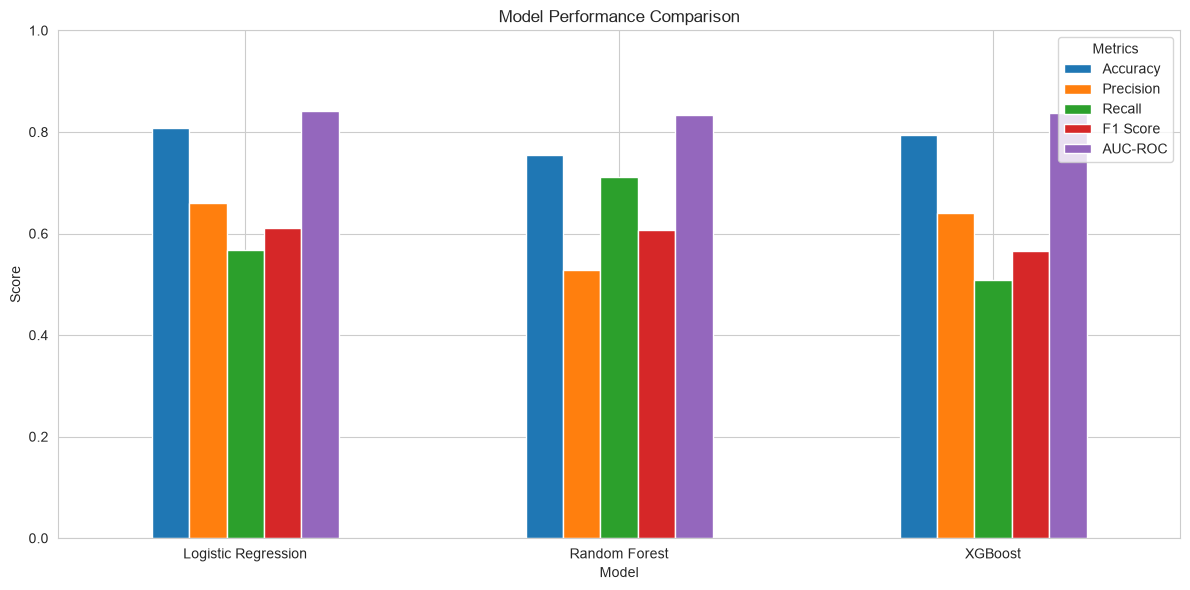

In [38]:
# Model Performance Comparison - Bar Chart

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]

model_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

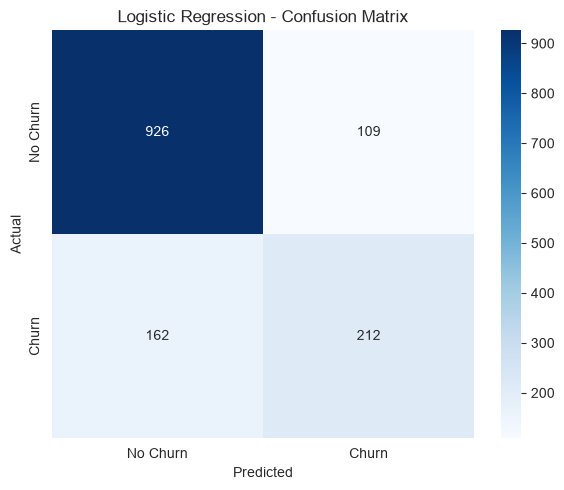

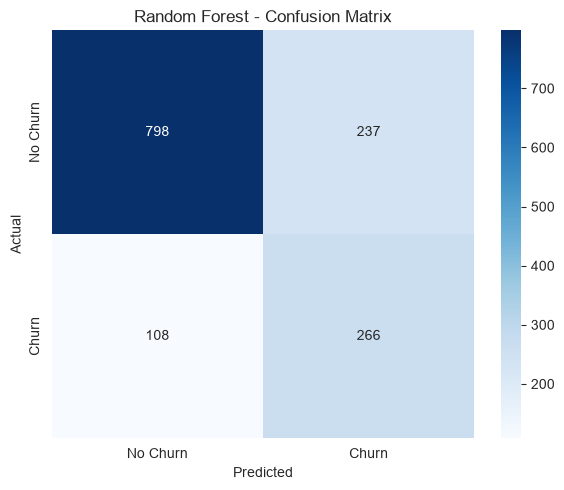

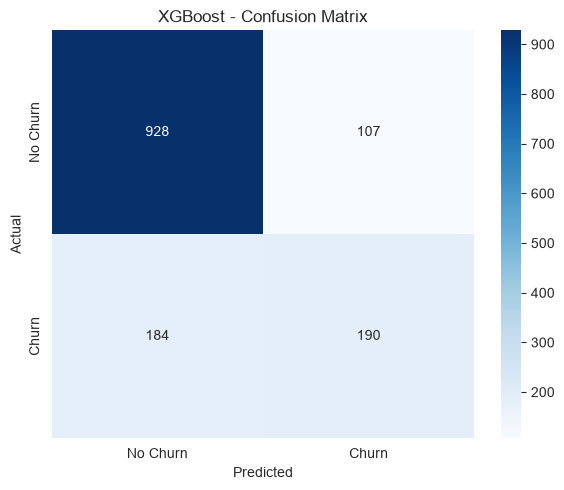

In [39]:
# Confusion Matrix for All Models

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

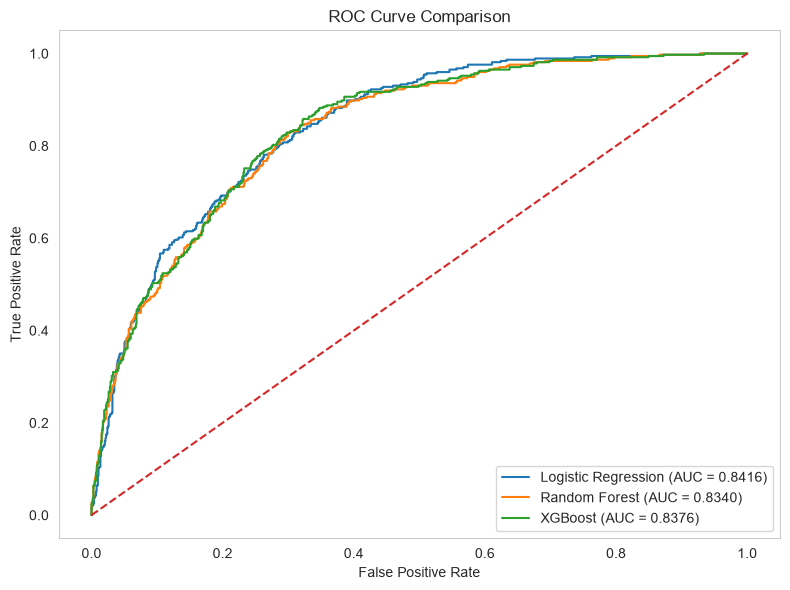

In [40]:
# ROC Curve Comparison

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Calculate ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Calculate AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.4f})"
)

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [41]:
# ==========================================
# K-Fold Cross-Validation
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression Cross-Validation
cv_scores_lr = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression - 5-Fold Cross-Validation")
print("-" * 50)
print("Fold Scores:", cv_scores_lr)
print("Mean AUC-ROC:", round(cv_scores_lr.mean(), 4))
print("Standard Deviation:", round(cv_scores_lr.std(), 4))

Logistic Regression - 5-Fold Cross-Validation
--------------------------------------------------
Fold Scores: [0.8476726  0.82452579 0.84081399 0.86148474 0.85284685]
Mean AUC-ROC: 0.8455
Standard Deviation: 0.0125


In [42]:
# ==========================================
# Random Forest - 5-Fold Cross-Validation
# ==========================================

cv_scores_rf = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest - 5-Fold Cross-Validation")
print("-" * 50)
print("Fold Scores:", cv_scores_rf)
print("Mean AUC-ROC:", round(cv_scores_rf.mean(), 4))
print("Standard Deviation:", round(cv_scores_rf.std(), 4))

Random Forest - 5-Fold Cross-Validation
--------------------------------------------------
Fold Scores: [0.83304655 0.82518015 0.83821474 0.84238928 0.85117663]
Mean AUC-ROC: 0.838
Standard Deviation: 0.0087


In [43]:
# ==========================================
# XGBoost - 5-Fold Cross-Validation
# ==========================================

cv_scores_xgb = cross_val_score(
    xgb_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost - 5-Fold Cross-Validation")
print("-" * 50)
print("Fold Scores:", cv_scores_xgb)
print("Mean AUC-ROC:", round(cv_scores_xgb.mean(), 4))
print("Standard Deviation:", round(cv_scores_xgb.std(), 4))

XGBoost - 5-Fold Cross-Validation
--------------------------------------------------
Fold Scores: [0.83495508 0.82774102 0.83677274 0.84643255 0.84913436]
Mean AUC-ROC: 0.839
Standard Deviation: 0.0078


In [44]:
# ==========================================
# Hyperparameter Tuning - Logistic Regression
# ==========================================

from sklearn.model_selection import GridSearchCV

# Define parameter grid
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [500, 1000]
}

# Create GridSearchCV
lr_grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=lr_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit GridSearchCV
lr_grid_search.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression - GridSearchCV")
print("-" * 50)

print("Best Parameters:")
print(lr_grid_search.best_params_)

print("\nBest Cross-Validation AUC-ROC:")
print(round(lr_grid_search.best_score_, 4))

Logistic Regression - GridSearchCV
--------------------------------------------------
Best Parameters:
{'C': 100, 'max_iter': 500, 'solver': 'liblinear'}

Best Cross-Validation AUC-ROC:
0.8453


In [45]:
# Best Logistic Regression Model

best_lr_model = lr_grid_search.best_estimator_

print("Best Logistic Regression model selected successfully")
print(best_lr_model)

Best Logistic Regression model selected successfully
LogisticRegression(C=100, max_iter=500, random_state=42, solver='liblinear')


In [46]:
# ==========================================
# Hyperparameter Tuning - Random Forest
# ==========================================

from sklearn.model_selection import GridSearchCV

# Define parameter grid
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Create GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit GridSearchCV
rf_grid_search.fit(
    X_train_processed,
    y_train
)

print("Random Forest - GridSearchCV")
print("-" * 50)

print("Best Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation AUC-ROC:")
print(round(rf_grid_search.best_score_, 4))

Random Forest - GridSearchCV
--------------------------------------------------
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation AUC-ROC:
0.8456


In [47]:
# Best Random Forest Model

best_rf_model = rf_grid_search.best_estimator_

print("Best Random Forest model selected successfully")
print(best_rf_model)

Best Random Forest model selected successfully
RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)


In [48]:
# ==========================================
# Hyperparameter Tuning - XGBoost
# ==========================================

from sklearn.model_selection import GridSearchCV

# Define parameter grid
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

# Create GridSearchCV
xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit GridSearchCV
xgb_grid_search.fit(
    X_train_processed,
    y_train
)

print("XGBoost - GridSearchCV")
print("-" * 50)

print("Best Parameters:")
print(xgb_grid_search.best_params_)

print("\nBest Cross-Validation AUC-ROC:")
print(round(xgb_grid_search.best_score_, 4))

XGBoost - GridSearchCV
--------------------------------------------------
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Best Cross-Validation AUC-ROC:
0.8472


In [49]:
# ==========================================
# Best XGBoost Model
# ==========================================

best_xgb_model = xgb_grid_search.best_estimator_

print("Best XGBoost model selected successfully")
print(best_xgb_model)

Best XGBoost model selected successfully
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [50]:
# ==========================================
# Final Test Set Evaluation - Tuned Models
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# -----------------------------
# Logistic Regression
# -----------------------------
y_pred_lr = best_lr_model.predict(X_test_processed)
y_prob_lr = best_lr_model.predict_proba(X_test_processed)[:, 1]

accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr)
precision_lr_tuned = precision_score(y_test, y_pred_lr)
recall_lr_tuned = recall_score(y_test, y_pred_lr)
f1_lr_tuned = f1_score(y_test, y_pred_lr)
auc_lr_tuned = roc_auc_score(y_test, y_prob_lr)


# -----------------------------
# Random Forest
# -----------------------------
y_pred_rf = best_rf_model.predict(X_test_processed)
y_prob_rf = best_rf_model.predict_proba(X_test_processed)[:, 1]

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf)
precision_rf_tuned = precision_score(y_test, y_pred_rf)
recall_rf_tuned = recall_score(y_test, y_pred_rf)
f1_rf_tuned = f1_score(y_test, y_pred_rf)
auc_rf_tuned = roc_auc_score(y_test, y_prob_rf)


# -----------------------------
# XGBoost
# -----------------------------
y_pred_xgb = best_xgb_model.predict(X_test_processed)
y_prob_xgb = best_xgb_model.predict_proba(X_test_processed)[:, 1]

accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb)
auc_xgb_tuned = roc_auc_score(y_test, y_prob_xgb)


# ==========================================
# Display Final Results
# ==========================================

print("Final Test Set Performance")
print("=" * 60)

print("\nLogistic Regression")
print("Accuracy :", round(accuracy_lr_tuned, 4))
print("Precision:", round(precision_lr_tuned, 4))
print("Recall   :", round(recall_lr_tuned, 4))
print("F1 Score :", round(f1_lr_tuned, 4))
print("AUC-ROC  :", round(auc_lr_tuned, 4))

print("\nRandom Forest")
print("Accuracy :", round(accuracy_rf_tuned, 4))
print("Precision:", round(precision_rf_tuned, 4))
print("Recall   :", round(recall_rf_tuned, 4))
print("F1 Score :", round(f1_rf_tuned, 4))
print("AUC-ROC  :", round(auc_rf_tuned, 4))

print("\nXGBoost")
print("Accuracy :", round(accuracy_xgb_tuned, 4))
print("Precision:", round(precision_xgb_tuned, 4))
print("Recall   :", round(recall_xgb_tuned, 4))
print("F1 Score :", round(f1_xgb_tuned, 4))
print("AUC-ROC  :", round(auc_xgb_tuned, 4))

Final Test Set Performance

Logistic Regression
Accuracy : 0.7991
Precision: 0.6417
Recall   : 0.5508
F1 Score : 0.5928
AUC-ROC  : 0.8403

Random Forest
Accuracy : 0.7523
Precision: 0.5229
Recall   : 0.762
F1 Score : 0.6202
AUC-ROC  : 0.8386

XGBoost
Accuracy : 0.8048
Precision: 0.6713
Recall   : 0.5187
F1 Score : 0.5852
AUC-ROC  : 0.8456


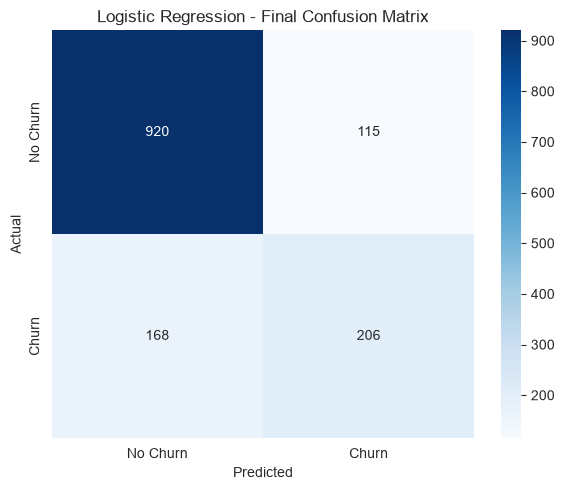

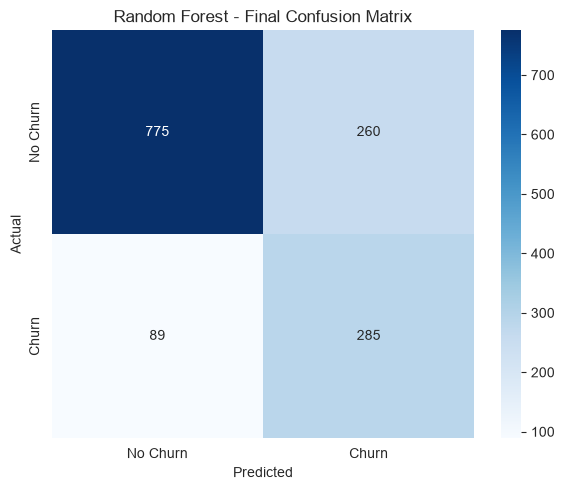

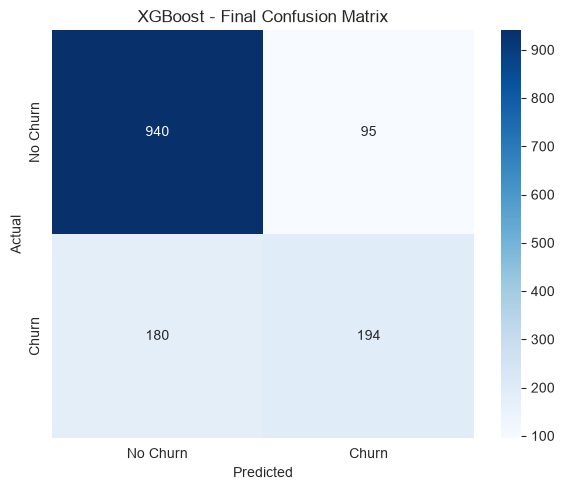

In [51]:
# ==========================================
# Final Confusion Matrices - Tuned Models
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, y_pred in models_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"{model_name} - Final Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

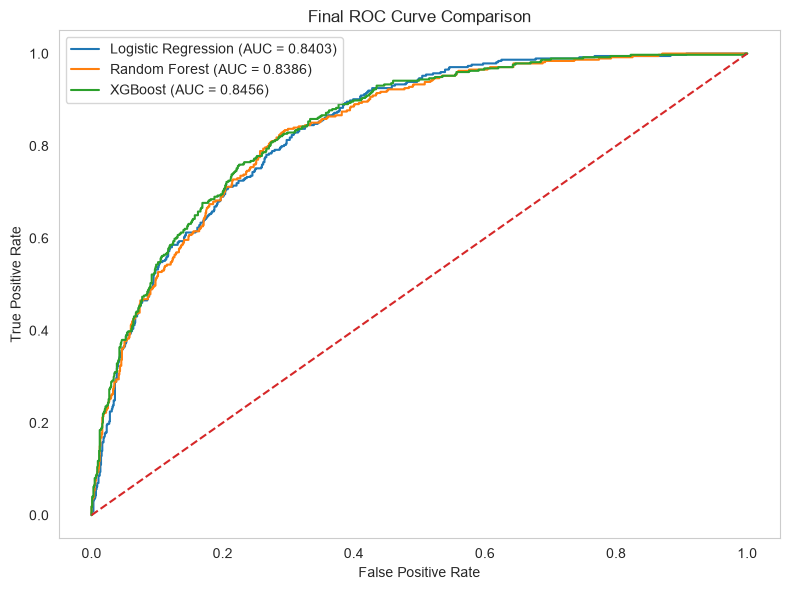

In [52]:
# ==========================================
# Final ROC Curve Comparison - Tuned Models
# ==========================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Calculate AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_xgb:.4f})"
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve Comparison")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [53]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


c:\Users\hemal\OneDrive\Documents\Projects\Predictive_Customer_Churn_Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of features: 48
Processed test data shape: (1409, 48)


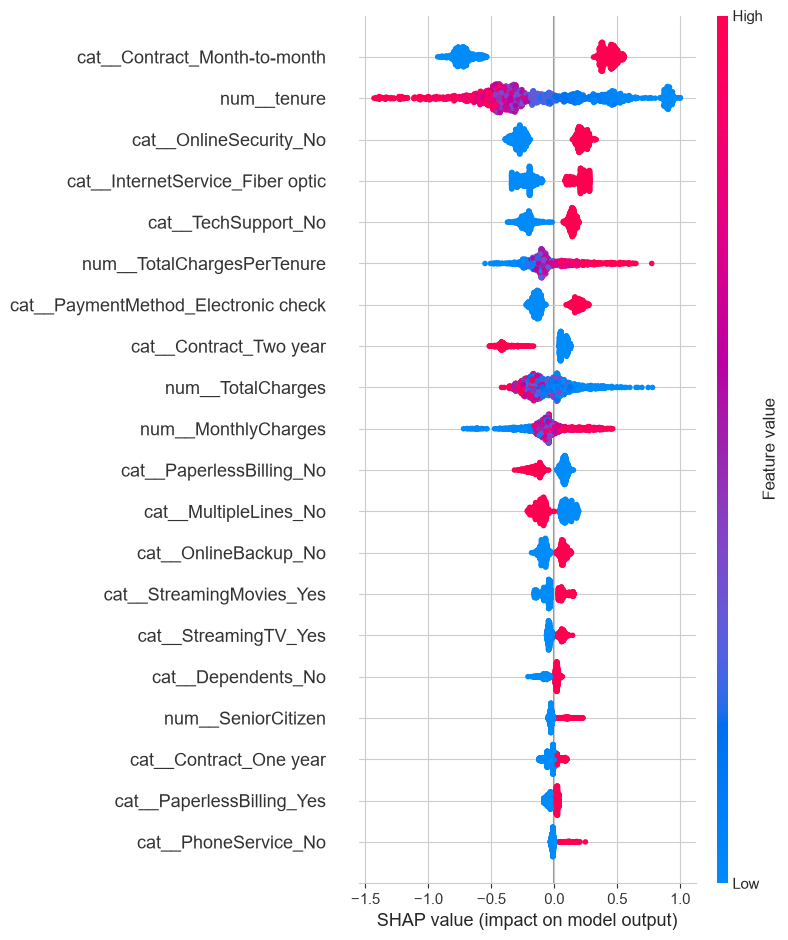

In [54]:
# ==========================================
# SHAP Analysis - XGBoost Model
# ==========================================

import shap

# Get actual feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

# Convert processed test data into DataFrame
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("Processed test data shape:", X_test_processed_df.shape)

# Create SHAP explainer
explainer = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_processed_df)

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    max_display=20,
    show=True
)

In [55]:
# ==========================================
# Save Final XGBoost Model and Preprocessor
# ==========================================

import joblib
import os

# Create model directory
os.makedirs("../model", exist_ok=True)

# Save trained XGBoost model
joblib.dump(best_xgb_model, "../model/churn_xgb_model.pkl")

# Save preprocessing pipeline
joblib.dump(preprocessor, "../model/preprocessor.pkl")

# Save feature names
joblib.dump(feature_names, "../model/feature_names.pkl")

print("Model and preprocessing files saved successfully!")

Model and preprocessing files saved successfully!


In [56]:
# ==========================================
# Test Saved XGBoost Model
# ==========================================

import joblib

# Load saved files
loaded_model = joblib.load("../model/churn_xgb_model.pkl")
loaded_preprocessor = joblib.load("../model/preprocessor.pkl")

# Process test data
X_test_saved = loaded_preprocessor.transform(X_test)

# Make predictions
y_pred_saved = loaded_model.predict(X_test_saved)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_saved))
print("First 10 predictions:", y_pred_saved[:10])

Predictions generated successfully!
Number of predictions: 1409
First 10 predictions: [0 1 0 0 0 1 0 0 0 0]


In [57]:
# ==========================================
# Verify Saved XGBoost Model Performance
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predicted probabilities
y_prob_saved = loaded_model.predict_proba(X_test_saved)[:, 1]

# Calculate metrics
accuracy_saved = accuracy_score(y_test, y_pred_saved)
precision_saved = precision_score(y_test, y_pred_saved)
recall_saved = recall_score(y_test, y_pred_saved)
f1_saved = f1_score(y_test, y_pred_saved)
auc_saved = roc_auc_score(y_test, y_prob_saved)

print("Saved XGBoost Model Performance")
print("=" * 45)
print("Accuracy :", round(accuracy_saved, 4))
print("Precision:", round(precision_saved, 4))
print("Recall   :", round(recall_saved, 4))
print("F1 Score :", round(f1_saved, 4))
print("AUC-ROC  :", round(auc_saved, 4))

Saved XGBoost Model Performance
Accuracy : 0.8048
Precision: 0.6713
Recall   : 0.5187
F1 Score : 0.5852
AUC-ROC  : 0.8456
